## Univariate Time series forcasting using LSTM

In [2]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Flatten

In [1]:
import tensorflow as tf

print(tf.__version__)


2.15.0


In [3]:
## preparing independent and dependent features
def prepare_data(timeseries_data, n_features):
    X, y = [], []
    for i in range(len(timeseries_data)):
        # find the end of this pattern
        end_idx = i + n_features
        # check if we are beyond the sequence
        if end_idx > len(timeseries_data) - 1:
            break
        # gather input and output parts of the pattern
        seq_x, seq_y = timeseries_data[i:end_idx], timeseries_data[end_idx]
        X.append(seq_x)
        y.append(seq_y)
    return np.array(X), np.array(y)

In [4]:
# define input sequence
timeseries_data = [110, 125, 133, 146, 158, 172, 187, 196, 210]
#choose a number of time steps
n_steps = 3
#split into samples
X, y = prepare_data(timeseries_data, n_steps)
print(X.shape, y.shape)

(6, 3) (6,)


In [5]:
# reshape from [samples, timesteps] into [samples, timesteps, features]
n_features = 1
X = X.reshape((X.shape[0], X.shape[1], n_features))
print(X.shape, y.shape)

(6, 3, 1) (6,)


In [6]:
# building LSTM model
model = Sequential()
model.add(LSTM(50, activation='relu', return_sequences=True, input_shape=(n_steps, n_features)))
model.add(LSTM(50, activation='relu'))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')
model.fit(X, y, epochs=200, verbose=0)

In [9]:
# Predicting for next 10 data
X_input = np.array([187, 196, 210])
temp_input=list(X_input)
lst_output=[]
i=0

while(i<10):
    if len(temp_input)>n_steps:
        #print(temp_input)
        X_input=np.array(temp_input[1:])
        print("{} day input {}".format(i, X_input))
        X_input=X_input.reshape((1,n_steps,n_features))
        yhat=model.predict(X_input, verbose=0)
        print("{} day output {}".format(i,yhat))
        temp_input.append(yhat[0][0])
        temp_input=temp_input[1:]
        lst_output.append(yhat[0][0])
        i=i+1
    else:
        X_input=X_input.reshape((1,n_steps,n_features))
        yhat=model.predict(X_input, verbose=0)
        temp_input.append(yhat[0][0])
        lst_output.append(yhat[0][0])
        i=i+1

print(lst_output)

1 day input [196.         210.         226.84005737]
1 day output [[238.51797]]
2 day input [210.         226.84005737 238.51797485]
2 day output [[254.74197]]
3 day input [226.84006 238.51797 254.74197]
3 day output [[272.0683]]
4 day input [238.51797 254.74197 272.0683 ]
4 day output [[287.10443]]
5 day input [254.74197 272.0683  287.10443]
5 day output [[305.69873]]
6 day input [272.0683  287.10443 305.69873]
6 day output [[324.81073]]
7 day input [287.10443 305.69873 324.81073]
7 day output [[343.54022]]
8 day input [305.69873 324.81073 343.54022]
8 day output [[364.97046]]
9 day input [324.81073 343.54022 364.97046]
9 day output [[386.9997]]
[226.84006, 238.51797, 254.74197, 272.0683, 287.10443, 305.69873, 324.81073, 343.54022, 364.97046, 386.9997]


In [ ]:
# timeseries_data = [110, 125, 133, 146, 158, 172, 187, 196, 210]
# lst_output=[187.0, 196.0, 210.0, 217.0, 222.0, 226.0, 230.0, 234.0, 238.0, 241.0]

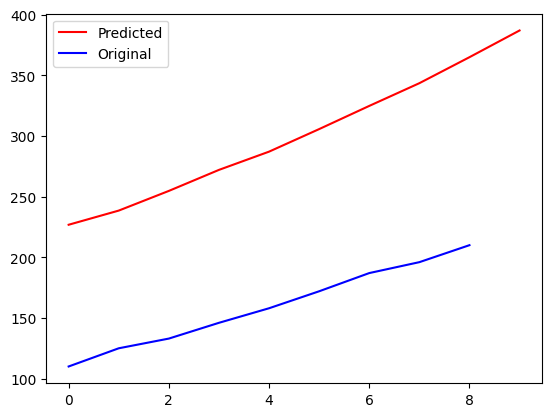

In [10]:
## visualizing the results
import matplotlib.pyplot as plt
plt.plot(lst_output, 'r', label='Predicted')
plt.plot(timeseries_data, 'b', label='Original')
plt.legend()
plt.show()

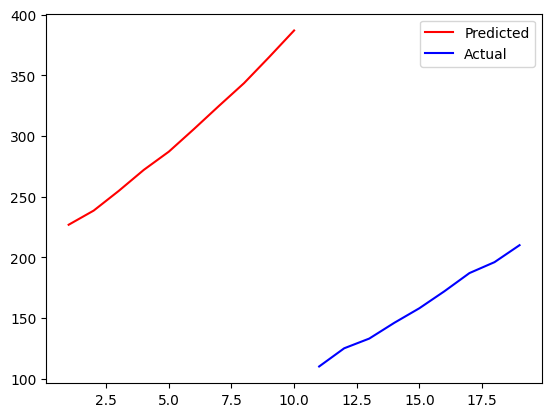

In [13]:
day_new = np.arange(1, 11)
day_pred = np.arange(11, 20)
plt.plot(day_new, lst_output, color='red', label='Predicted')
plt.plot(day_pred, timeseries_data, color='blue', label='Actual')
plt.legend()
plt.show()